# Part 2 of 4 — Eigenfaces (1 Mark)
COMP3710 Lab Demonstration 2

Principal Component Analysis (PCA) of the "Labeled Faces in the Wild" (LFW) dataset: compute the
eigenfaces via eigen-decomposition (SVD), visualise them, evaluate how compact the representation
is, and use the PCA-reduced features to train a Random Forest face classifier.

## 2.1 Load the data

In [1]:
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt

# Download the data, if not already on disk, and load it as numpy arrays
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

## 2.2 Extract the meaningful parameters of the faces dataset

In [2]:
# introspect the images arrays to find the shapes (for plotting)
n_samples, h, w = lfw_people.images.shape

# for machine learning we use the 2D data directly (as relative pixel
# positions info is ignored by this model)
X = lfw_people.data
n_features = X.shape[1]

# the label to predict is the id of the person
y = lfw_people.target
target_names = lfw_people.target_names
n_classes = target_names.shape[0]

print("Total dataset size:")
print("n_samples: %d" % n_samples)
print("n_features: %d" % n_features)
print("n_classes: %d" % n_classes)
print("image shape: (%d, %d)" % (h, w))
print("people:", list(target_names))

Total dataset size:
n_samples: 1288
n_features: 1850
n_classes: 7
image shape: (50, 37)
people: [np.str_('Ariel Sharon'), np.str_('Colin Powell'), np.str_('Donald Rumsfeld'), np.str_('George W Bush'), np.str_('Gerhard Schroeder'), np.str_('Hugo Chavez'), np.str_('Tony Blair')]


## 2.3 Train/test split

In [3]:
# Split into a training set and a test set using a stratified k fold
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Compute a PCA (eigenfaces) on the face dataset (treated as unlabeled
# dataset): unsupervised feature extraction / dimensionality reduction
n_components = 150

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (966, 1850)
X_test shape: (322, 1850)


## 2.4 PCA via eigen-decomposition (SVD)

In [4]:
# Center data
mean = np.mean(X_train, axis=0)
X_train -= mean
X_test -= mean

# Eigen-decomposition
U, S, V = np.linalg.svd(X_train, full_matrices=False)
components = V[:n_components]
eigenfaces = components.reshape((n_components, h, w))

# project into PCA subspace
X_transformed = np.dot(X_train, components.T)
print(X_transformed.shape)

X_test_transformed = np.dot(X_test, components.T)
print(X_test_transformed.shape)

(966, 150)
(322, 150)


## 2.5 Plot the eigenfaces

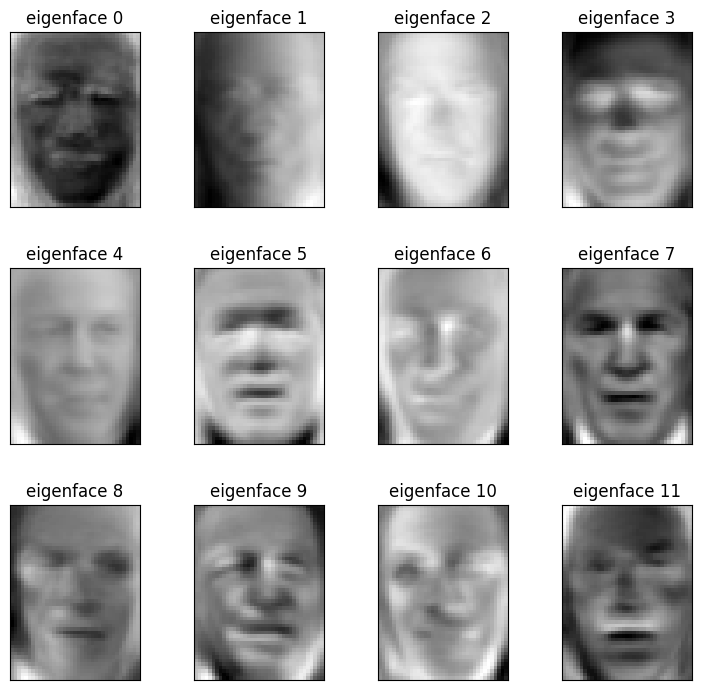

In [5]:
# Qualitative evaluation of the predictions using matplotlib
def plot_gallery(images, titles, h, w, n_row=3, n_col=4):
    """Helper function to plot a gallery of portraits"""
    plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.35)
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i].reshape((h, w)), cmap=plt.cm.gray)
        plt.title(titles[i], size=12)
        plt.xticks(())
        plt.yticks(())

eigenface_titles = ["eigenface %d" % i for i in range(eigenfaces.shape[0])]
plot_gallery(eigenfaces, eigenface_titles, h, w)
plt.show()

## 2.6 Compactness of the representation

(966,)


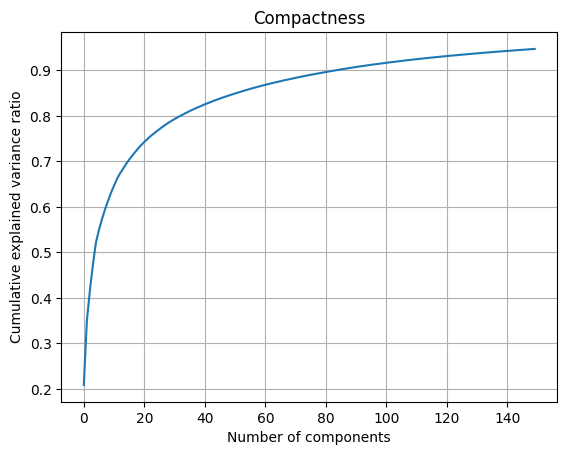

Variance explained by first 10 components: 0.631
Variance explained by first 50 components: 0.847
Variance explained by all 150 components: 0.947
(For reference, all 966 available components would explain 1.000 — trivially 100%, since that keeps every direction, no reduction at all)


In [6]:
explained_variance = (S ** 2) / (n_samples - 1)
total_var = explained_variance.sum()
explained_variance_ratio = explained_variance / total_var
ratio_cumsum = np.cumsum(explained_variance_ratio)
print(ratio_cumsum.shape)

eigenvalueCount = np.arange(n_components)

plt.plot(eigenvalueCount, ratio_cumsum[:n_components])
plt.title('Compactness')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance ratio')
plt.grid(True)
plt.show()

print(f"Variance explained by first 10 components: {ratio_cumsum[9]:.3f}")
print(f"Variance explained by first 50 components: {ratio_cumsum[49]:.3f}")
print(f"Variance explained by all {n_components} components: {ratio_cumsum[n_components - 1]:.3f}")
print(f"(For reference, all {len(ratio_cumsum)} available components would explain {ratio_cumsum[-1]:.3f} — "
      f"trivially 100%, since that keeps every direction, no reduction at all)")

## 2.7 Random Forest classifier on PCA (eigenface) features

In [7]:
from sklearn.ensemble import RandomForestClassifier

# build random forest
estimator = RandomForestClassifier(n_estimators=150, max_depth=15, max_features=150, random_state=42)
estimator.fit(X_transformed, y_train)  # expects X as [n_samples, n_features]

predictions = estimator.predict(X_test_transformed)
correct = predictions == y_test
total_test = len(X_test_transformed)

print("Total Testing", total_test)
print("Predictions", predictions)
print("Which Correct:", correct)
print("Total Correct:", np.sum(correct))
print("Accuracy:", np.sum(correct) / total_test)

print(classification_report(y_test, predictions, target_names=target_names))

Total Testing 322
Predictions [3 3 4 3 3 3 3 1 3 3 3 4 3 3 3 3 4 3 3 4 1 1 3 3 3 1 3 3 3 3 3 3 3 3 3 3 3
 3 3 1 3 3 3 1 1 3 3 3 4 3 3 3 3 3 1 2 1 3 5 3 6 1 3 6 3 5 3 4 1 2 6 4 3 3
 3 2 3 3 3 3 6 3 3 3 3 3 3 3 3 1 5 6 3 3 1 3 1 1 1 6 3 3 3 3 3 3 3 3 3 1 3
 1 6 3 3 3 1 4 1 3 1 3 3 1 3 4 5 3 1 3 6 6 6 3 3 4 3 3 1 6 3 3 3 1 3 3 3 3
 4 1 1 3 1 3 3 3 6 3 3 3 4 5 5 1 3 3 5 1 3 3 1 3 3 1 5 3 3 3 3 5 3 3 1 3 3
 3 3 3 3 2 5 3 2 3 6 3 3 3 3 3 3 2 3 3 5 1 4 2 6 3 3 5 3 3 4 4 3 1 3 3 3 3
 3 1 1 3 3 3 2 3 3 3 3 3 3 1 3 6 3 3 3 4 3 3 4 3 3 3 3 4 4 2 3 4 3 4 3 1 3
 3 3 3 3 1 3 5 4 1 6 1 6 1 3 3 6 3 3 3 3 3 1 1 3 3 3 1 3 3 3 4 3 3 5 3 3 3
 3 4 3 3 3 6 6 3 1 3 3 3 3 3 3 3 1 3 3 3 3 1 3 3 5 3]
Which Correct: [ True  True False  True  True  True False  True  True  True  True False
  True False  True  True False  True  True  True  True False  True False
 False  True False  True  True  True False  True  True  True  True  True
  True  True  True  True  True False  True  True  True False False  True
 False  T

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

**This shows the performance of the RF/PCA-based face recognition (as required for the 1 mark).**

## 2.8 A more readable summary

`predictions` and `correct` above are raw numeric arrays (322 entries each) — correct, but not
very readable at a glance. This section turns them into (a) a small human-readable table using
real names instead of label numbers, and (b) a visual "gallery" of a few test photos with their
predicted vs. true name — the kind of thing worth showing a demonstrator directly.

In [8]:
# --- (a) A readable name-based table for the first few test samples ---
n_show = 20
print(f"{'#':>4}  {'True name':<20} {'Predicted name':<20} {'Correct?'}")
print("-" * 60)
for i in range(n_show):
    true_name = target_names[y_test[i]]
    pred_name = target_names[predictions[i]]
    mark = "correct" if correct[i] else "WRONG"
    print(f"{i:>4}  {true_name:<20} {pred_name:<20} {mark}")
print(f"... ({total_test - n_show} more test samples not shown)")

print(f"\nOverall: {np.sum(correct)} / {total_test} correct = {np.sum(correct) / total_test:.4f} accuracy")

   #  True name            Predicted name       Correct?
------------------------------------------------------------
   0  George W Bush        George W Bush        correct
   1  George W Bush        George W Bush        correct
   2  Tony Blair           Gerhard Schroeder    WRONG
   3  George W Bush        George W Bush        correct
   4  George W Bush        George W Bush        correct
   5  George W Bush        George W Bush        correct
   6  Gerhard Schroeder    George W Bush        WRONG
   7  Colin Powell         Colin Powell         correct
   8  George W Bush        George W Bush        correct
   9  George W Bush        George W Bush        correct
  10  George W Bush        George W Bush        correct
  11  George W Bush        Gerhard Schroeder    WRONG
  12  George W Bush        George W Bush        correct
  13  Tony Blair           George W Bush        WRONG
  14  George W Bush        George W Bush        correct
  15  George W Bush        George W Bush        co

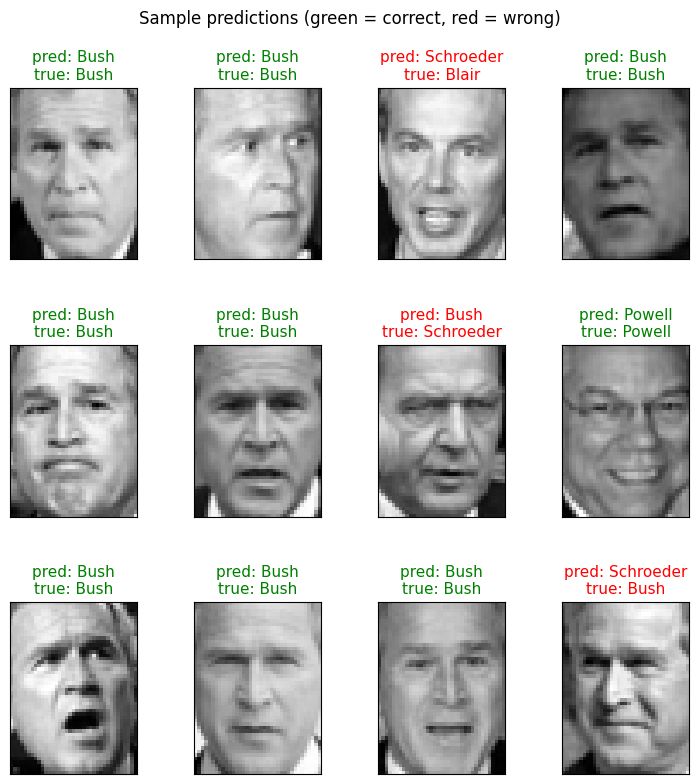

In [9]:
# --- (b) A visual gallery: some test photos with predicted vs. true name ---
def plot_prediction_gallery(images, y_pred, y_true, target_names, h, w, n_row=3, n_col=4):
    """Like plot_gallery, but titles show predicted/true name, coloured green if
    correct and red if wrong."""
    plt.figure(figsize=(1.8 * n_col, 2.6 * n_row))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.88, hspace=.5)
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i].reshape((h, w)), cmap=plt.cm.gray)
        pred_name = target_names[y_pred[i]].rsplit(' ', 1)[-1]   # just the surname, keeps titles short
        true_name = target_names[y_true[i]].rsplit(' ', 1)[-1]
        is_correct = y_pred[i] == y_true[i]
        plt.title(f"pred: {pred_name}\ntrue: {true_name}",
                   size=11, color=("green" if is_correct else "red"))
        plt.xticks(())
        plt.yticks(())

# X_test had the training mean subtracted back in §2.4 (X_test -= mean), so add it back
# to display the actual photo instead of a "difference from mean" image.
X_test_display = X_test + mean
plot_prediction_gallery(X_test_display, predictions, y_test, target_names, h, w)
plt.suptitle("Sample predictions (green = correct, red = wrong)", y=0.98)
plt.show()